In [1]:
# --- CELL 1: SETUP ---
import os
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver # <--- IMPORTANT: For saving state
from IPython.display import Image, display

# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [2]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    invoice_id: str
    amount: float
    vendor: str
    status: str           # e.g., "Draft", "Pending Approval", "Executed"
    human_decision: str   # "Approve" or "Reject"

In [10]:
# --- CELL 3: THE NODES ---

def invoice_parser_node(state: SentinelState):
    print(f"\n🔍 Sentinel: Parsing Invoice {state['invoice_id']}...")
    return {"amount": 5500.00, "vendor": "Cloud-Systems Inc.", "status": "Draft"}

def gatekeeper_node(state: SentinelState):
    print("⚖️ Gatekeeper: Checking transaction risk...")
    if state["amount"] > 1000:
        return {"status": "Pending Approval"}
    return {"status": "Auto-Approved"}

def payment_executor_node(state: SentinelState):
    # Here, we check what YOU typed in the console
    if state.get("human_decision", "").lower() == "approve":
        print(f"💰 SUCCESS: Paid ${state['amount']} to {state['vendor']}.")
        return {"status": "Executed"}
    else:
        print("❌ Payment CANCELLED per human instruction.")
        return {"status": "Cancelled"}

In [11]:
# --- CELL 4: THE GRAPH ---
builder = StateGraph(SentinelState)
builder.add_node("parser", invoice_parser_node)
builder.add_node("gatekeeper", gatekeeper_node)
builder.add_node("executor", payment_executor_node)

builder.add_edge(START, "parser")
builder.add_edge("parser", "gatekeeper")

# Routing Logic
def route_logic(state: SentinelState):
    return "wait_for_human" if state["status"] == "Pending Approval" else "execute"

builder.add_conditional_edges("gatekeeper", route_logic, {
    "wait_for_human": "executor",
    "execute": "executor"
})
builder.add_edge("executor", END)

# IMPORTANT: We interrupt before 'executor' to wait for YOU
memory = MemorySaver()
sentinel_live = builder.compile(checkpointer=memory, interrupt_before=["executor"])

In [12]:
# --- CELL 5: PHASE 1 - RUNNING THE AGENT ---
thread_config = {"configurable": {"thread_id": "real_human_test_1"}}
print("--- AGENT STARTING ---")

# The agent runs until it hits the 'executor' node and stops.
for event in sentinel_live.stream({"invoice_id": "INV-999"}, thread_config):
    pass

--- AGENT STARTING ---

🔍 Sentinel: Parsing Invoice INV-999...
⚖️ Gatekeeper: Checking transaction risk...


In [13]:
# --- CELL 6: PHASE 2 - THE ACTUAL HUMAN INPUT ---
# This is where the magic happens. We ask the user for input in the notebook.
current_state = sentinel_live.get_state(thread_config)

if current_state.next: # Check if the graph is actually paused
    print(f"\n📢 ACTION REQUIRED: Invoice for ${current_state.values['amount']} needs review.")

    # ACTUAL HUMAN INPUT HERE
    user_choice = input("Type 'Approve' to pay or 'Reject' to cancel: ")

    # We update the agent's memory with YOUR decision
    sentinel_live.update_state(thread_config, {"human_decision": user_choice})

    print("\n--- RESUMING AGENT ---")
    for event in sentinel_live.stream(None, thread_config):
        pass


📢 ACTION REQUIRED: Invoice for $5500.0 needs review.

--- RESUMING AGENT ---
💰 SUCCESS: Paid $5500.0 to Cloud-Systems Inc..


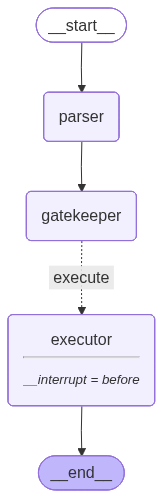

In [14]:
# --- CELL 7: VISUALIZATION ---
try:
    png_bytes = sentinel_live.get_graph().draw_mermaid_png()
    with open("sentinel_hitl.png", "wb") as f:
        f.write(png_bytes)
    display(Image(data=png_bytes))
except Exception as e:
    print(f"Visualization skip: {e}")